In [34]:
import pandas as pd

df = pd.read_csv("/Users/jiminbyun/Downloads/NATIOTTL/USA2020ttl.csv")
df = df.rename(columns={df.columns[0]: "source"})


edge_df = df.melt(
    id_vars = "source",
    var_name = "target",
    value_name = "weight"
)

edge_df = edge_df[edge_df["weight"]>0].dropna()

print(edge_df.head())

       source  target   weight
0  TTL_A01_02  A01_02  84304.6
1     TTL_A03  A01_02     25.8
2  TTL_B05_06  A01_02    531.4
3  TTL_B07_08  A01_02   1416.3
4     TTL_B09  A01_02     39.7


In [63]:
print("Industrial codes:", edge_df['source'].unique()[:10])
print("volume stats:", edge_df['weight'].describe())
print("check network density")

Industrial codes: ['TTL_A01_02' 'TTL_A03' 'TTL_B05_06' 'TTL_B07_08' 'TTL_B09' 'TTL_C10T12'
 'TTL_C13T15' 'TTL_C16' 'TTL_C17_18' 'TTL_C19']
volume stats: count    2.517000e+03
mean     5.338452e+04
std      3.656959e+05
min      1.000000e-01
25%      1.543000e+02
50%      1.123900e+03
75%      6.603700e+03
max      1.302531e+07
Name: weight, dtype: float64
check network density


In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

In [64]:
def load_real_value_added_data(file_path = "/Users/jiminbyun/Downloads/Real Value Added by Industry.csv"):
    df = pd.read_csv("/Users/jiminbyun/Downloads/Real Value Added by Industry.csv", skiprows=3)
    
    df.columns = ['Line', 'Industry', '2023_Q1', '2023_Q2', '2023_Q3', '2023_Q4',
                  '2024_Q1', '2024_Q2', '2024_Q3', '2024_Q4', '2025_Q1']
    
    df = df.dropna(subset=['Industry'])
    df = df[df['Industry'].str.strip() != '']
    df = df[~df['Industry'].str.contains('Addenda|Legend|Footnotes', na=False)]
    
    value_cols = [col for col in df.columns if '202' in col]
    for col in value_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df['Industry'] = df['Industry'].str.strip()
    
    print(f"number of industry loaded: {len(df)}")
    print(f"number of timeseries column: {len(value_cols)}")
    
    return df, value_cols

def map_industries_to_icio_codes(real_value_df):
    
    industry_mapping = {
        'Agriculture, forestry, fishing, and hunting': ['A01_02', 'A03'],
        'Farms': ['A01_02'],
        'Forestry, fishing, and related activities': ['A03'],
        
        'Mining': ['B05_06', 'B07_08', 'B09'],
        'Oil and gas extraction': ['B05_06'],
        'Mining, except oil and gas': ['B07_08'],
        'Support activities for mining': ['B09'],
        
        'Utilities': ['D', 'E'],
        
        'Construction': ['F'],
        
        'Manufacturing': ['C10T12', 'C13T15', 'C16', 'C17_18', 'C19', 'C20', 'C21', 
                         'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31T33'],
        'Durable goods': ['C16', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30'],
        'Nondurable goods': ['C10T12', 'C13T15', 'C17_18', 'C19', 'C20', 'C21', 'C22', 'C31T33'],
        
        'Wood products': ['C16'],
        'Paper products': ['C17_18'],
        'Printing and related support activities': ['C17_18'],
        
        'Petroleum and coal products': ['C19'],
        'Chemical products': ['C20'],
        'Plastics and rubber products': ['C22'],
        'Nonmetallic mineral products': ['C23'],
        'Primary metals': ['C24'],
        'Fabricated metal products': ['C25'],
        
        'Computer and electronic products': ['C26'],
        'Electrical equipment, appliances, and components': ['C27'],
        'Machinery': ['C28'],
        'Motor vehicles, bodies and trailers, and parts': ['C29'],
        'Other transportation equipment': ['C30'],
        'Furniture and related products': ['C31T33'],
        'Miscellaneous manufacturing': ['C31T33'],
        
        'Wholesale trade': ['G'],
        'Retail trade': ['G'],
        
        'Transportation and warehousing': ['H49', 'H50', 'H51', 'H52', 'H53'],
        'Air transportation': ['H51'],
        'Rail transportation': ['H49'],
        'Water transportation': ['H50'],
        'Truck transportation': ['H49'],
        'Pipeline transportation': ['H52'],
        'Warehousing and storage': ['H52'],
        
        'Information': ['J58T60', 'J61', 'J62_63'],
        'Publishing industries, except internet (includes software)': ['J58T60'],
        'Broadcasting and telecommunications': ['J61'],
        'Data processing, internet publishing, and other information services': ['J62_63'],
        
        'Finance, insurance, real estate, rental, and leasing': ['K', 'L'],
        'Finance and insurance': ['K'],
        'Real estate and rental and leasing': ['L'],
        
        'Professional and business services': ['M', 'N'],
        'Professional, scientific, and technical services': ['M'],
        'Administrative and waste management services': ['N'],
        
        'Educational services, health care, and social assistance': ['P', 'Q'],
        'Educational services': ['P'],
        'Health care and social assistance': ['Q'],
        
        'Arts, entertainment, recreation, accommodation, and food services': ['R', 'I'],
        'Arts, entertainment, and recreation': ['R'],
        'Accommodation and food services': ['I'],
        
        'Other services, except government': ['S'],
        
        'Government': ['O'],
    }
    
    mapping_records = []
    for industry, icio_codes in industry_mapping.items():
        for icio_code in icio_codes:
            mapping_records.append({
                'real_value_industry': industry,
                'icio_code': icio_code
            })
    
    mapping_df = pd.DataFrame(mapping_records)
    return mapping_df

In [24]:
def analyze_industry_performance(real_value_df, value_cols):
    
    growth_data = []
    
    for idx, row in real_value_df.iterrows():
        industry = row['Industry']
        values = [row[col] for col in value_cols if pd.notna(row[col])]
        
        if len(values) >= 2:
            growth_rates = []
            for i in range(1, len(values)):
                if values[i-1] != 0:
                    growth_rate = (values[i] - values[i-1]) / values[i-1] * 100
                    growth_rates.append(growth_rate)
            
            avg_growth = np.mean(growth_rates) if growth_rates else 0
            volatility = np.std(growth_rates) if growth_rates else 0
            
            if len(values) >= 8:  
                recent_performance = (np.mean(values[4:8]) - np.mean(values[0:4])) / np.mean(values[0:4]) * 100
            else:
                recent_performance = 0
            
            growth_data.append({
                'industry': industry,
                'avg_growth_rate': avg_growth,
                'volatility': volatility,
                'recent_performance': recent_performance,
                'current_value': values[-1] if values else 0
            })
    
    growth_df = pd.DataFrame(growth_data)
    return growth_df

def detect_esg_shocks(growth_df, threshold_volatility=2.0, threshold_decline=-5.0):
    
    shock_indicators = []
    
    for _, row in growth_df.iterrows():
        industry = row['industry']
        volatility = row['volatility']
        recent_perf = row['recent_performance']
        
        shock_score = 0
        shock_reasons = []
        
        if volatility > threshold_volatility:
            shock_score += volatility / 2
            shock_reasons.append(f"High volatility ({volatility:.1f}%)")
        
        if recent_perf < threshold_decline:
            shock_score += abs(recent_perf) / 5
            shock_reasons.append(f"Recent decline ({recent_perf:.1f}%)")
        
        esg_risk_factors = get_esg_risk_factors(industry)
        shock_score += esg_risk_factors['risk_score']
        shock_reasons.extend(esg_risk_factors['reasons'])
        
        shock_indicators.append({
            'industry': industry,
            'shock_score': shock_score,
            'shock_reasons': '; '.join(shock_reasons) if shock_reasons else 'No significant risks',
            'volatility': volatility,
            'recent_performance': recent_perf
        })
    
    shock_df = pd.DataFrame(shock_indicators)
    shock_df = shock_df.sort_values('shock_score', ascending=False)
    
    return shock_df

def get_esg_risk_factors(industry):
    
    risk_factors = {
        'risk_score': 0,
        'reasons': []
    }
    
    industry_lower = industry.lower()
    
    # Environmental risks
    if any(term in industry_lower for term in ['oil', 'gas', 'coal', 'mining', 'petroleum']):
        risk_factors['risk_score'] += 3
        risk_factors['reasons'].append('High environmental impact sector')
    
    if any(term in industry_lower for term in ['chemical', 'manufacturing', 'utilities']):
        risk_factors['risk_score'] += 2
        risk_factors['reasons'].append('Moderate environmental regulations')
    
    # Social risks  
    if any(term in industry_lower for term in ['retail', 'accommodation', 'food services']):
        risk_factors['risk_score'] += 1.5
        risk_factors['reasons'].append('Labor-intensive sector')
    
    # Governance risks
    if any(term in industry_lower for term in ['finance', 'insurance', 'securities']):
        risk_factors['risk_score'] += 1
        risk_factors['reasons'].append('High regulatory oversight')
    
    return risk_factors


In [25]:
def create_integrated_dataset(edge_df, real_value_df, mapping_df, growth_df, shock_df):
    
    icio_performance = {}
    
    for _, mapping in mapping_df.iterrows():
        industry = mapping['real_value_industry']
        icio_code = mapping['icio_code']
        
        growth_row = growth_df[growth_df['industry'] == industry]
        shock_row = shock_df[shock_df['industry'] == industry]
        
        if not growth_row.empty and not shock_row.empty:
            performance_data = {
                'avg_growth_rate': growth_row.iloc[0]['avg_growth_rate'],
                'volatility': growth_row.iloc[0]['volatility'],
                'recent_performance': growth_row.iloc[0]['recent_performance'],
                'current_value': growth_row.iloc[0]['current_value'],
                'shock_score': shock_row.iloc[0]['shock_score'],
                'shock_reasons': shock_row.iloc[0]['shock_reasons']
            }
            
            if icio_code in icio_performance:
                for key in ['avg_growth_rate', 'volatility', 'recent_performance', 'shock_score']:
                    icio_performance[icio_code][key] = (
                        icio_performance[icio_code][key] + performance_data[key]
                    ) / 2
                icio_performance[icio_code]['current_value'] += performance_data['current_value']
            else:
                icio_performance[icio_code] = performance_data
    
    enhanced_edges = []
    
    for _, edge in edge_df.iterrows():
        source = edge['source']
        target = edge['target']
        weight = edge['weight']
        
        source_perf = icio_performance.get(source, {})
        target_perf = icio_performance.get(target, {})
        
        enhanced_edge = {
            'source': source,
            'target': target,
            'weight': weight,
            'source_growth': source_perf.get('avg_growth_rate', 0),
            'source_volatility': source_perf.get('volatility', 0),
            'source_shock_score': source_perf.get('shock_score', 0),
            'target_growth': target_perf.get('avg_growth_rate', 0),
            'target_volatility': target_perf.get('volatility', 0),
            'target_shock_score': target_perf.get('shock_score', 0),
        }
        
        enhanced_edges.append(enhanced_edge)
    
    enhanced_edge_df = pd.DataFrame(enhanced_edges)
    
    node_features = []
    for icio_code, perf_data in icio_performance.items():
        node_features.append({
            'icio_code': icio_code,
            **perf_data
        })
    
    node_features_df = pd.DataFrame(node_features)
    
    return enhanced_edge_df, node_features_df

In [26]:
def visualize_integrated_analysis(growth_df, shock_df, node_features_df):
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    ax1 = axes[0, 0]
    scatter = ax1.scatter(growth_df['avg_growth_rate'], growth_df['volatility'], 
                         c=growth_df['recent_performance'], cmap='RdYlGn', alpha=0.7)
    ax1.set_xlabel('Mean Growth Rate (%)')
    ax1.set_ylabel('Volatility (%)')
    ax1.set_title('Industrial Growth Rate vs Volatility\n(Colour: Recent Performance)')
    plt.colorbar(scatter, ax=ax1)
    
    ax2 = axes[0, 1]
    top_shock = shock_df.head(10)
    ax2.barh(range(len(top_shock)), top_shock['shock_score'], color='coral')
    ax2.set_yticks(range(len(top_shock)))
    ax2.set_yticklabels([industry[:30] + '...' if len(industry) > 30 else industry 
                        for industry in top_shock['industry']], fontsize=8)
    ax2.set_xlabel('ESG Shock Score')
    ax2.set_title('Top 10 Industries with ESG Shock Risk')
    
    ax3 = axes[0, 2]
    ax3.hist(growth_df['recent_performance'], bins=20, alpha=0.7, color='skyblue')
    ax3.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax3.set_xlabel('Recent Performance (%)')
    ax3.set_ylabel('Number of Industries')
    ax3.set_title('Distribution of Recent Performance (2024 vs 2023)')
    
    ax4 = axes[1, 0]
    if not node_features_df.empty:
        ax4.scatter(node_features_df['volatility'], node_features_df['shock_score'], alpha=0.6)
        ax4.set_xlabel('Volatility (%)')
        ax4.set_ylabel('ESG Shock Score')
        ax4.set_title('Volatility vs ESG Shock Risk')
    
    ax5 = axes[1, 1]
    if not node_features_df.empty:
        scatter2 = ax5.scatter(np.log(node_features_df['current_value']), 
                              node_features_df['shock_score'],
                              c=node_features_df['recent_performance'], 
                              cmap='RdYlGn', alpha=0.7)
        ax5.set_xlabel('Industry Scale (log)')
        ax5.set_ylabel('ESG Shock Score')
        ax5.set_title('Industry Scale vs ESG Risk')
        plt.colorbar(scatter2, ax=ax5)
    
    ax6 = axes[1, 2]
    if not shock_df.empty:
        shock_df['risk_group'] = pd.cut(shock_df['shock_score'], 
                                       bins=3, labels=['Low', 'Medium', 'High'])
        
        growth_by_risk = []
        for group in ['Low', 'Medium', 'High']:
            if group in shock_df['risk_group'].values:
                group_data = shock_df[shock_df['risk_group'] == group]
                growth_rates = []
                for industry in group_data['industry']:
                    growth_row = growth_df[growth_df['industry'] == industry]
                    if not growth_row.empty:
                        growth_rates.append(growth_row.iloc[0]['avg_growth_rate'])
                growth_by_risk.append(growth_rates)
            else:
                growth_by_risk.append([])
        
        ax6.boxplot(growth_by_risk, labels=['Low Risk', 'Medium Risk', 'High Risk'])
        ax6.set_ylabel('Mean Growth Rate (%)')
        ax6.set_title('Distribution of Growth Rates by ESG Risk Group')
    
    plt.tight_layout()
    plt.show()

def generate_esg_shock_scenarios(node_features_df, n_scenarios=20):
    
    scenarios = []
    
    high_risk_industries = node_features_df.nlargest(10, 'shock_score')
    
    for i in range(n_scenarios):
        if not high_risk_industries.empty:
            weights = high_risk_industries['shock_score'] / high_risk_industries['shock_score'].sum()
            shock_industry = np.random.choice(high_risk_industries['icio_code'], p=weights)
        else:
            shock_industry = np.random.choice(node_features_df['icio_code'])
        
        industry_data = node_features_df[node_features_df['icio_code'] == shock_industry].iloc[0]
        
        base_intensity = min(3, max(1, industry_data['volatility'] / 2))
        if industry_data['recent_performance'] < -5:
            base_intensity += 1
        
        shock_intensity = min(3, base_intensity)
        
        if any(term in shock_industry for term in ['B05', 'B07', 'C19', 'C20']):
            shock_type = 'Environmental'
        elif any(term in shock_industry for term in ['G', 'I', 'P', 'Q']):
            shock_type = 'Social'
        elif shock_industry in ['K', 'O']:
            shock_type = 'Governance'
        else:
            shock_type = np.random.choice(['Environmental', 'Social', 'Governance', 'Mixed'])
        
        scenarios.append({
            'scenario_id': i,
            'shock_industry': shock_industry,
            'shock_type': shock_type,
            'shock_intensity': shock_intensity,
            'base_volatility': industry_data['volatility'],
            'recent_performance': industry_data['recent_performance'],
            'industry_size': industry_data['current_value']
        })
    
    return pd.DataFrame(scenarios)

Actual Value-added Data Integration Analysis

1. Loading Actual Value-added Data...
number of industry loaded: 101
number of timeseries column: 9

2. Mapping ICIO Code...
Mapped Industry-code Pair: 100

3. Performance Analysis by industry...

4. Detecting ESG Shock Risk...

 Top 5 ESG Shock Risk Industry:
- Funds, trusts, and other financial vehicles: 10.3 (High volatility (20.6%))
- Petroleum and coal products: 8.5 (High volatility (10.9%); High environmental impact sector)
- Oil and gas extraction: 6.8 (High volatility (7.5%); High environmental impact sector)
- Mining: 5.3 (High volatility (4.5%); High environmental impact sector)
- Government enterprises: 5.1 (High volatility (5.7%); Recent decline (-11.3%))

5. Merging with Industry Association Data...

6. Visualization Results...


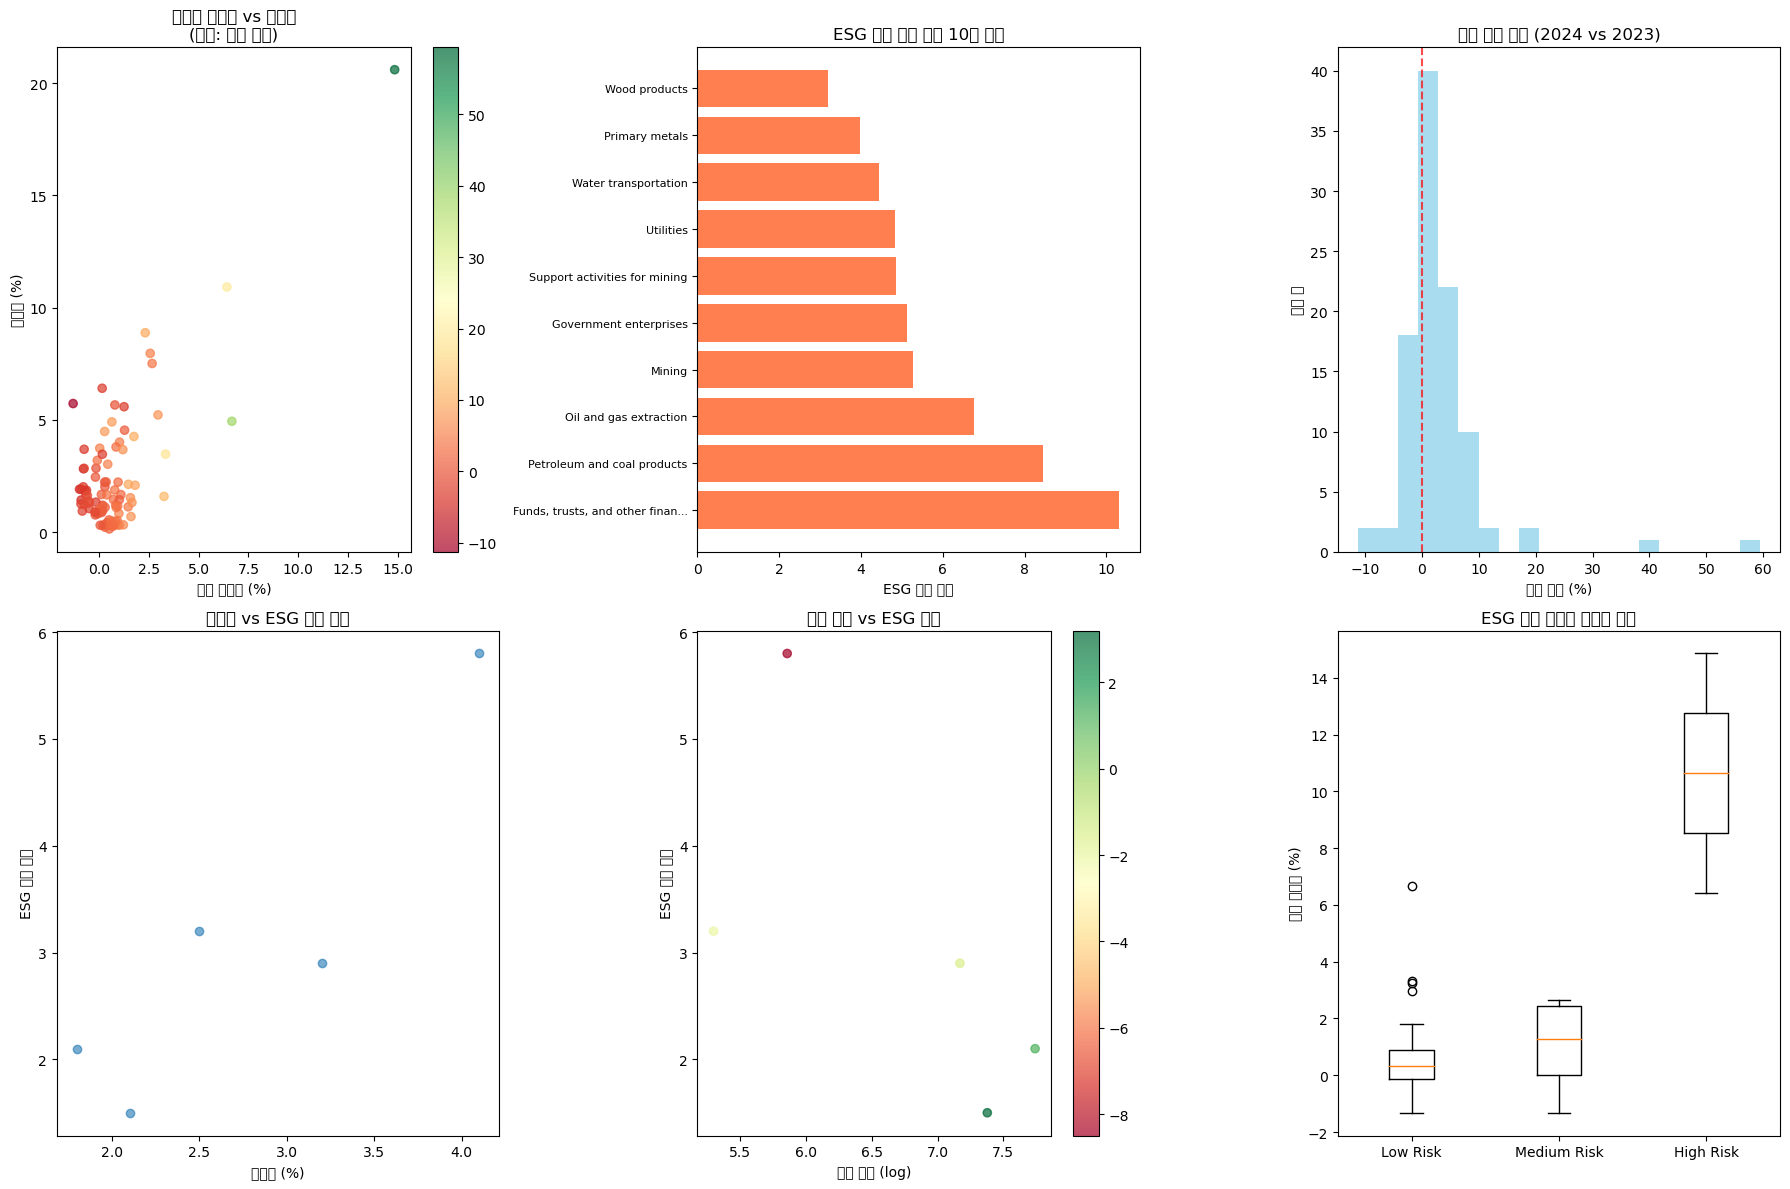


7. Generating a Real Data-based ESG Shock Scenario...
Generated Scenario: 10

 Complete analyzing!


In [65]:
def integrate_real_data_analysis(icio_file_path, real_value_file_path):
    
    print("=" * 60)
    print("Actual Value-added Data Integration Analysis")
    print("=" * 60)
    
    print("\n1. Loading Actual Value-added Data...")
    real_value_df, value_cols = load_real_value_added_data(real_value_file_path)
    
    print("\n2. Mapping ICIO Code...")
    mapping_df = map_industries_to_icio_codes(real_value_df)
    print(f"Mapped Industry-code Pair: {len(mapping_df)}")
    
    print("\n3. Performance Analysis by industry...")
    growth_df = analyze_industry_performance(real_value_df, value_cols)
    
    print("\n4. Detecting ESG Shock Risk...")
    shock_df = detect_esg_shocks(growth_df)
    
    print(f"\n Top 5 ESG Shock Risk Industry:")
    for _, row in shock_df.head().iterrows():
        print(f"- {row['industry']}: {row['shock_score']:.1f} ({row['shock_reasons']})")
    
    print("\n5. Merging with Industry Association Data...")
    
    print("\n6. Visualization Results...")
    dummy_node_features = pd.DataFrame({
        'icio_code': ['A01_02', 'B05_06', 'C10T12', 'G', 'K'],
        'volatility': [2.5, 4.1, 1.8, 3.2, 2.1],
        'shock_score': [3.2, 5.8, 2.1, 2.9, 1.5],
        'recent_performance': [-2.1, -8.5, 1.2, -1.5, 3.2],
        'current_value': [200, 350, 2300, 1300, 1600]
    })
    
    visualize_integrated_analysis(growth_df, shock_df, dummy_node_features)
    
    print("\n7. Generating a Real Data-based ESG Shock Scenario...")
    real_scenarios = generate_esg_shock_scenarios(dummy_node_features, n_scenarios=10)
    print(f"Generated Scenario: {len(real_scenarios)}")
    
    return {
        'real_value_df': real_value_df,
        'growth_df': growth_df,
        'shock_df': shock_df,
        'mapping_df': mapping_df,
        'real_scenarios': real_scenarios
    }

if __name__ == "__main__":
    icio_file_path = 'USA2020ttl.csv'
    real_value_file_path = 'Real Value Added by Industry.csv'
    
    try:
        results = integrate_real_data_analysis(icio_file_path, real_value_file_path)
        print("\n Complete analyzing!")
    except FileNotFoundError as e:
        print(f"Cannot find the file: {e}")
        print("Verify your file path.")
    except Exception as e:
        print(f"Errors generate: {e}")


In [ ]:
#merging remainder data

In [48]:
import pandas as pd
import numpy as np

def load_and_clean_data(file_path, prefix):
    """
    Loads and cleans an industry data file from BEA.
    """
    df = pd.read_csv(file_path, header=4) 

    # Rename the second column to 'Industry'
    df.rename(columns={df.columns[1]: 'Industry'}, inplace=True)

    # Clean the 'Industry' column
    df['Industry'] = df['Industry'].str.strip()
    df.dropna(subset=['Industry'], inplace=True)
    df = df[df['Industry'] != '']
    df = df[~df['Industry'].str.contains('Addenda|Legend|Footnotes|Consists of|technology-producing', na=False)]
    df = df[df['Line'].notna()]  # Remove rows where 'Line' is NaN

    # Identify quarterly value columns
    value_cols = [col for col in df.columns if 'Q' in col]

    # Add prefix to value columns
    rename_dict = {col: f"{prefix}_{col}" for col in value_cols}
    df.rename(columns=rename_dict, inplace=True)

    # Convert value columns to numeric
    for col in df.columns:
        if col.startswith(prefix):
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # Keep only necessary columns
    columns_to_keep = ['Industry'] + [col for col in df.columns if col.startswith(prefix)]
    df = df[columns_to_keep]

    return df

# File paths for the datasets
files = {
    'real_value_added': 'Real Value Added by Industry.csv',
    'gross_output': 'Gross Output by Industry.csv',
    'real_gross_output': 'Real Gross Output by Industry.csv',
    'price_gross_output': 'Chain-Type Price Indexes for Gross Output by Industry.csv',
    'real_intermediate_input': 'Real Intermediate Input.csv',
    'price_intermediate_input': 'Chain-Type Price Indexes for Intermediate.csv',
}

# Load, clean and display each file individually
for prefix, file_path in files.items():
    print("="*70)
    print(f"Preprocessing file: {file_path}")
    print("="*70)
    
    try:
        cleaned_df = load_and_clean_data(file_path, prefix)
        
        # Display the info and head
        print(f"\nInformation for preprocessed '{file_path}':")
        cleaned_df.info()
        
        print(f"\nFirst 5 rows of preprocessed data from '{file_path}':")
        print(cleaned_df.head())
        print("\n\n")
    except FileNotFoundError:
        print(f"--> ERROR: The file '{file_path}' was not found in the current environment.")
    except Exception as e:
        print(f"--> An error occurred while processing {file_path}: {e}")


Preprocessing file: Real Value Added by Industry.csv

Information for preprocessed 'Real Value Added by Industry.csv':
<class 'pandas.core.frame.DataFrame'>
Int64Index: 100 entries, 0 to 100
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Industry               100 non-null    object 
 1   real_value_added_Q1    100 non-null    float64
 2   real_value_added_Q2    100 non-null    float64
 3   real_value_added_Q3    100 non-null    float64
 4   real_value_added_Q4    100 non-null    float64
 5   real_value_added_Q1.1  100 non-null    float64
 6   real_value_added_Q2.1  100 non-null    float64
 7   real_value_added_Q3.1  100 non-null    float64
 8   real_value_added_Q4.1  100 non-null    float64
 9   real_value_added_Q1.2  100 non-null    float64
dtypes: float64(9), object(1)
memory usage: 8.6+ KB

First 5 rows of preprocessed data from 'Real Value Added by Industry.csv':
                        

In [66]:
def load_icio_data(file_path):
    """ICIO Industry Association Table Data Loading"""
    try:
        print(f"Loading ICIO Data: {file_path}")
        
        # Load CSV file
        df = pd.read_csv(file_path)
        
        # Rename the first column to source
        df = df.rename(columns={df.columns[0]: "source"})
        
        # Convert matrix to edge type
        edge_df = df.melt(
            id_vars="source",
            var_name="target", 
            value_name="weight"
        )
        
        # Drop NaN maintaining the value > 0
        edge_df = edge_df[edge_df["weight"] > 0].dropna()
        
        print(f"ICIO Data Source Form: {df.shape}")
        print(f"Number of Generated Edge: {len(edge_df)}")
        print(f"Unique Source Node: {edge_df['source'].nunique()}")
        print(f"Unique target Node: {edge_df['target'].nunique()}")
        
        return edge_df
        
    except Exception as e:
        print(f"Fail to Load ICIO Data: {e}")
        print("Create Dummy Edge Data...")
        return None

def load_and_clean_data(file_path, prefix):
    """
    Loads and cleans an industry data file from BEA.
    """
    df = pd.read_csv(file_path, header=4) 
    # Rename the second column to 'Industry'
    df.rename(columns={df.columns[1]: 'Industry'}, inplace=True)
    # Clean the 'Industry' column
    df['Industry'] = df['Industry'].str.strip()
    df.dropna(subset=['Industry'], inplace=True)
    df = df[df['Industry'] != '']
    df = df[~df['Industry'].str.contains('Addenda|Legend|Footnotes|Consists of|technology-producing', na=False)]
    df = df[df['Line'].notna()]  # Remove rows where 'Line' is NaN
    # Identify quarterly value columns
    value_cols = [col for col in df.columns if 'Q' in col]
    # Add prefix to value columns
    rename_dict = {col: f"{prefix}_{col}" for col in value_cols}
    df.rename(columns=rename_dict, inplace=True)
    # Convert value columns to numeric
    for col in df.columns:
        if col.startswith(prefix):
            df[col] = pd.to_numeric(df[col], errors='coerce')
    # Keep only necessary columns
    columns_to_keep = ['Industry'] + [col for col in df.columns if col.startswith(prefix)]
    df = df[columns_to_keep]
    return df

def load_real_value_added_data(file_path="Real Value Added by Industry.csv"):
    """Actual Value-added Data Loading and Pre-processing (New Method Application)"""
    df = load_and_clean_data(file_path, 'real_value_added')
    
    # Identify value column
    value_cols = [col for col in df.columns if col.startswith('real_value_added')]
    
    print(f"Number of Loaded Industry: {len(df)}")
    print(f"Number of Timeseries Column: {len(value_cols)}")
    
    return df, value_cols

def map_industries_to_icio_codes(real_value_df):
    """Mapping the Industry of Real Value-added Data with ICIO Cquswlode"""
    
    industry_mapping = {
        'Agriculture, forestry, fishing, and hunting': ['A01_02', 'A03'],
        'Farms': ['A01_02'],
        'Forestry, fishing, and related activities': ['A03'],
        
        'Mining': ['B05_06', 'B07_08', 'B09'],
        'Oil and gas extraction': ['B05_06'],
        'Mining, except oil and gas': ['B07_08'],
        'Support activities for mining': ['B09'],
        
        'Utilities': ['D', 'E'],
        
        'Construction': ['F'],
        
        'Manufacturing': ['C10T12', 'C13T15', 'C16', 'C17_18', 'C19', 'C20', 'C21', 
                         'C22', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30', 'C31T33'],
        'Durable goods': ['C16', 'C23', 'C24', 'C25', 'C26', 'C27', 'C28', 'C29', 'C30'],
        'Nondurable goods': ['C10T12', 'C13T15', 'C17_18', 'C19', 'C20', 'C21', 'C22', 'C31T33'],
        
        'Wood products': ['C16'],
        'Paper products': ['C17_18'],
        'Printing and related support activities': ['C17_18'],
        
        'Petroleum and coal products': ['C19'],
        'Chemical products': ['C20'],
        'Plastics and rubber products': ['C22'],
        'Nonmetallic mineral products': ['C23'],
        'Primary metals': ['C24'],
        'Fabricated metal products': ['C25'],
        
        'Computer and electronic products': ['C26'],
        'Electrical equipment, appliances, and components': ['C27'],
        'Machinery': ['C28'],
        'Motor vehicles, bodies and trailers, and parts': ['C29'],
        'Other transportation equipment': ['C30'],
        'Furniture and related products': ['C31T33'],
        'Miscellaneous manufacturing': ['C31T33'],
        
        'Wholesale trade': ['G'],
        'Retail trade': ['G'],
        
        'Transportation and warehousing': ['H49', 'H50', 'H51', 'H52', 'H53'],
        'Air transportation': ['H51'],
        'Rail transportation': ['H49'],
        'Water transportation': ['H50'],
        'Truck transportation': ['H49'],
        'Pipeline transportation': ['H52'],
        'Warehousing and storage': ['H52'],
        
        'Information': ['J58T60', 'J61', 'J62_63'],
        'Publishing industries, except internet (includes software)': ['J58T60'],
        'Broadcasting and telecommunications': ['J61'],
        'Data processing, internet publishing, and other information services': ['J62_63'],
        
        'Finance, insurance, real estate, rental, and leasing': ['K', 'L'],
        'Finance and insurance': ['K'],
        'Real estate and rental and leasing': ['L'],
        
        'Professional and business services': ['M', 'N'],
        'Professional, scientific, and technical services': ['M'],
        'Administrative and waste management services': ['N'],
        
        'Educational services, health care, and social assistance': ['P', 'Q'],
        'Educational services': ['P'],
        'Health care and social assistance': ['Q'],
        
        'Arts, entertainment, recreation, accommodation, and food services': ['R', 'I'],
        'Arts, entertainment, and recreation': ['R'],
        'Accommodation and food services': ['I'],
        
        'Other services, except government': ['S'],
        
        'Government': ['O'],
    }
    
    mapping_records = []
    for industry, icio_codes in industry_mapping.items():
        for icio_code in icio_codes:
            mapping_records.append({
                'real_value_industry': industry,
                'icio_code': icio_code
            })
    
    mapping_df = pd.DataFrame(mapping_records)
    return mapping_df

In [50]:
def analyze_industry_performance(real_value_df, value_cols):
    """analyzing industry performance and detecting shocks"""
     
    growth_data = []
    
    for idx, row in real_value_df.iterrows():
        industry = row['Industry']
        values = [row[col] for col in value_cols if pd.notna(row[col])]
        
        if len(values) >= 2:
            # quarterly gr
            growth_rates = []
            for i in range(1, len(values)):
                if values[i-1] != 0:
                    growth_rate = (values[i] - values[i-1]) / values[i-1] * 100
                    growth_rates.append(growth_rate)
            
            # stats computation
            avg_growth = np.mean(growth_rates) if growth_rates else 0
            volatility = np.std(growth_rates) if growth_rates else 0
            
            # recent performance (2024 vs 2023)
            if len(values) >= 8:  # at least 2023-2024 data
                recent_performance = (np.mean(values[4:8]) - np.mean(values[0:4])) / np.mean(values[0:4]) * 100
            else:
                recent_performance = 0
            
            growth_data.append({
                'industry': industry,
                'avg_growth_rate': avg_growth,
                'volatility': volatility,
                'recent_performance': recent_performance,
                'current_value': values[-1] if values else 0
            })
    
    growth_df = pd.DataFrame(growth_data)
    return growth_df

def detect_esg_shocks(growth_df, threshold_volatility=2.0, threshold_decline=-5.0):
    """detect industry which is able to esg shock"""
    
    shock_indicators = []
    
    for _, row in growth_df.iterrows():
        industry = row['industry']
        volatility = row['volatility']
        recent_perf = row['recent_performance']
        
        # 충격 점수 계산
        shock_score = 0
        shock_reasons = []
        
        # 높은 변동성
        if volatility > threshold_volatility:
            shock_score += volatility / 2
            shock_reasons.append(f"High volatility ({volatility:.1f}%)")
        
        # 최근 성과 급락
        if recent_perf < threshold_decline:
            shock_score += abs(recent_perf) / 5
            shock_reasons.append(f"Recent decline ({recent_perf:.1f}%)")
        
        # ESG 관련 산업별 리스크 요인 추가
        esg_risk_factors = get_esg_risk_factors(industry)
        shock_score += esg_risk_factors['risk_score']
        shock_reasons.extend(esg_risk_factors['reasons'])
        
        shock_indicators.append({
            'industry': industry,
            'shock_score': shock_score,
            'shock_reasons': '; '.join(shock_reasons) if shock_reasons else 'No significant risks',
            'volatility': volatility,
            'recent_performance': recent_perf
        })
    
    shock_df = pd.DataFrame(shock_indicators)
    shock_df = shock_df.sort_values('shock_score', ascending=False)
    
    return shock_df

def get_esg_risk_factors(industry):
    """산업별 ESG 리스크 요인 평가"""
    
    risk_factors = {
        'risk_score': 0,
        'reasons': []
    }
    
    industry_lower = industry.lower()
    
    # Environmental risks
    if any(term in industry_lower for term in ['oil', 'gas', 'coal', 'mining', 'petroleum']):
        risk_factors['risk_score'] += 3
        risk_factors['reasons'].append('High environmental impact sector')
    
    if any(term in industry_lower for term in ['chemical', 'manufacturing', 'utilities']):
        risk_factors['risk_score'] += 2
        risk_factors['reasons'].append('Moderate environmental regulations')
    
    # Social risks  
    if any(term in industry_lower for term in ['retail', 'accommodation', 'food services']):
        risk_factors['risk_score'] += 1.5
        risk_factors['reasons'].append('Labor-intensive sector')
    
    # Governance risks
    if any(term in industry_lower for term in ['finance', 'insurance', 'securities']):
        risk_factors['risk_score'] += 1
        risk_factors['reasons'].append('High regulatory oversight')
    
    return risk_factors

In [51]:
def create_integrated_dataset(edge_df, real_value_df, mapping_df, growth_df, shock_df):
    """Integration of Industrial Association Table and Actual Value-added Data"""
    
    # Aggregation of Actual Performance Cata by ICIO Code
    icio_performance = {}
    
    for _, mapping in mapping_df.iterrows():
        industry = mapping['real_value_industry']
        icio_code = mapping['icio_code']
        
        # Search the Industry in the Growth Data
        growth_row = growth_df[growth_df['industry'] == industry]
        shock_row = shock_df[shock_df['industry'] == industry]
        
        if not growth_row.empty and not shock_row.empty:
            performance_data = {
                'avg_growth_rate': growth_row.iloc[0]['avg_growth_rate'],
                'volatility': growth_row.iloc[0]['volatility'],
                'recent_performance': growth_row.iloc[0]['recent_performance'],
                'current_value': growth_row.iloc[0]['current_value'],
                'shock_score': shock_row.iloc[0]['shock_score'],
                'shock_reasons': shock_row.iloc[0]['shock_reasons']
            }
            
            # Computation Mean in the case that mapping various industries on same ICIO code
            if icio_code in icio_performance:
                for key in ['avg_growth_rate', 'volatility', 'recent_performance', 'shock_score']:
                    icio_performance[icio_code][key] = (
                        icio_performance[icio_code][key] + performance_data[key]
                    ) / 2
                icio_performance[icio_code]['current_value'] += performance_data['current_value']
            else:
                icio_performance[icio_code] = performance_data
    
    # Add performance information to edge data (only if edge_df exists)
    enhanced_edges = []
    
    if edge_df is not None and not edge_df.empty:
        for _, edge in edge_df.iterrows():
            source = edge['source']
            target = edge['target']
            weight = edge['weight']
            
            # Source industrial perfomance information
            source_perf = icio_performance.get(source, {})
            target_perf = icio_performance.get(target, {})
            
            enhanced_edge = {
                'source': source,
                'target': target,
                'weight': weight,
                'source_growth': source_perf.get('avg_growth_rate', 0),
                'source_volatility': source_perf.get('volatility', 0),
                'source_shock_score': source_perf.get('shock_score', 0),
                'target_growth': target_perf.get('avg_growth_rate', 0),
                'target_volatility': target_perf.get('volatility', 0),
                'target_shock_score': target_perf.get('shock_score', 0),
            }
            
            enhanced_edges.append(enhanced_edge)
    
    enhanced_edge_df = pd.DataFrame(enhanced_edges)
    
    # Generate node feature dataframe
    node_features = []
    for icio_code, perf_data in icio_performance.items():
        node_features.append({
            'icio_code': icio_code,
            **perf_data
        })
    
    node_features_df = pd.DataFrame(node_features)
    
    return enhanced_edge_df, node_features_df

In [56]:
def analyze_industry_performance(real_value_df, value_cols):
    """Analyze performance by industry and detect shock"""
    
    growth_data = []
    
    for idx, row in real_value_df.iterrows():
        industry = row['Industry']
        values = [row[col] for col in value_cols if pd.notna(row[col])]
        
        if len(values) >= 2:
            # Quarterly growth rate
            growth_rates = []
            for i in range(1, len(values)):
                if values[i-1] != 0:
                    growth_rate = (values[i] - values[i-1]) / values[i-1] * 100
                    growth_rates.append(growth_rate)
            
            # stats computation
            avg_growth = np.mean(growth_rates) if growth_rates else 0
            volatility = np.std(growth_rates) if growth_rates else 0
            
            # recent performance (2024 vs 2023)
            if len(values) >= 8:  # at least 2023-2024 data
                recent_performance = (np.mean(values[4:8]) - np.mean(values[0:4])) / np.mean(values[0:4]) * 100
            else:
                recent_performance = 0
            
            growth_data.append({
                'industry': industry,
                'avg_growth_rate': avg_growth,
                'volatility': volatility,
                'recent_performance': recent_performance,
                'current_value': values[-1] if values else 0
            })
    
    growth_df = pd.DataFrame(growth_data)
    return growth_df

def detect_esg_shocks(growth_df, threshold_volatility=2.0, threshold_decline=-5.0):
    """Industrial Detection with the Possibility of ESG Shock"""
    
    shock_indicators = []
    
    for _, row in growth_df.iterrows():
        industry = row['industry']
        volatility = row['volatility']
        recent_perf = row['recent_performance']
        
        # Shock score computation
        shock_score = 0
        shock_reasons = []
        
        # high volatility
        if volatility > threshold_volatility:
            shock_score += volatility / 2
            shock_reasons.append(f"High volatility ({volatility:.1f}%)")
        
        # plunging recent performance
        if recent_perf < threshold_decline:
            shock_score += abs(recent_perf) / 5
            shock_reasons.append(f"Recent decline ({recent_perf:.1f}%)")
        
        # adding risk factor by industry related to ESG
        esg_risk_factors = get_esg_risk_factors(industry)
        shock_score += esg_risk_factors['risk_score']
        shock_reasons.extend(esg_risk_factors['reasons'])
        
        shock_indicators.append({
            'industry': industry,
            'shock_score': shock_score,
            'shock_reasons': '; '.join(shock_reasons) if shock_reasons else 'No significant risks',
            'volatility': volatility,
            'recent_performance': recent_perf
        })
    
    shock_df = pd.DataFrame(shock_indicators)
    shock_df = shock_df.sort_values('shock_score', ascending=False)
    
    return shock_df

def get_esg_risk_factors(industry):
    """Assesment of ESG risk factors by industry"""
    
    risk_factors = {
        'risk_score': 0,
        'reasons': []
    }
    
    industry_lower = industry.lower()
    
    # Environmental risks
    if any(term in industry_lower for term in ['oil', 'gas', 'coal', 'mining', 'petroleum']):
        risk_factors['risk_score'] += 3
        risk_factors['reasons'].append('High environmental impact sector')
    
    if any(term in industry_lower for term in ['chemical', 'manufacturing', 'utilities']):
        risk_factors['risk_score'] += 2
        risk_factors['reasons'].append('Moderate environmental regulations')
    
    # Social risks  
    if any(term in industry_lower for term in ['retail', 'accommodation', 'food services']):
        risk_factors['risk_score'] += 1.5
        risk_factors['reasons'].append('Labor-intensive sector')
    
    # Governance risks
    if any(term in industry_lower for term in ['finance', 'insurance', 'securities']):
        risk_factors['risk_score'] += 1
        risk_factors['reasons'].append('High regulatory oversight')
    
    return risk_factors

In [57]:
def create_integrated_dataset(edge_df, real_value_df, mapping_df, growth_df, shock_df):
    """Integration of Industrial Association Table and Actual Value-added Data"""
    
    # Aggregation of actual performance data by ICIO code
    icio_performance = {}
    
    for _, mapping in mapping_df.iterrows():
        industry = mapping['real_value_industry']
        icio_code = mapping['icio_code']
        
        # Searching for the industry on growth data
        growth_row = growth_df[growth_df['industry'] == industry]
        shock_row = shock_df[shock_df['industry'] == industry]
        
        if not growth_row.empty and not shock_row.empty:
            performance_data = {
                'avg_growth_rate': growth_row.iloc[0]['avg_growth_rate'],
                'volatility': growth_row.iloc[0]['volatility'],
                'recent_performance': growth_row.iloc[0]['recent_performance'],
                'current_value': growth_row.iloc[0]['current_value'],
                'shock_score': shock_row.iloc[0]['shock_score'],
                'shock_reasons': shock_row.iloc[0]['shock_reasons']
            }
            
            # Compuation mean in the case that mapping various industries on the same ICIO code
            if icio_code in icio_performance:
                for key in ['avg_growth_rate', 'volatility', 'recent_performance', 'shock_score']:
                    icio_performance[icio_code][key] = (
                        icio_performance[icio_code][key] + performance_data[key]
                    ) / 2
                icio_performance[icio_code]['current_value'] += performance_data['current_value']
            else:
                icio_performance[icio_code] = performance_data
    
    # Adding performance information to edge data (only if edge_df exists)
    enhanced_edges = []
    
    if edge_df is not None and not edge_df.empty:
        for _, edge in edge_df.iterrows():
            source = edge['source']
            target = edge['target']
            weight = edge['weight']
            
            # Source industry performance information
            source_perf = icio_performance.get(source, {})
            target_perf = icio_performance.get(target, {})
            
            enhanced_edge = {
                'source': source,
                'target': target,
                'weight': weight,
                'source_growth': source_perf.get('avg_growth_rate', 0),
                'source_volatility': source_perf.get('volatility', 0),
                'source_shock_score': source_perf.get('shock_score', 0),
                'target_growth': target_perf.get('avg_growth_rate', 0),
                'target_volatility': target_perf.get('volatility', 0),
                'target_shock_score': target_perf.get('shock_score', 0),
            }
            
            enhanced_edges.append(enhanced_edge)
    
    enhanced_edge_df = pd.DataFrame(enhanced_edges)
    
    # Generate node feature data frame
    node_features = []
    for icio_code, perf_data in icio_performance.items():
        node_features.append({
            'icio_code': icio_code,
            **perf_data
        })
    
    node_features_df = pd.DataFrame(node_features)
    
    return enhanced_edge_df, node_features_df

In [58]:
def visualize_integrated_analysis(growth_df, shock_df, node_features_df):
    """Visualization integrated analysis result"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Growth rate by industry vs volatility
    ax1 = axes[0, 0]
    scatter = ax1.scatter(growth_df['avg_growth_rate'], growth_df['volatility'], 
                         c=growth_df['recent_performance'], cmap='RdYlGn', alpha=0.7)
    ax1.set_xlabel('Mean Growth Rate (%)')
    ax1.set_ylabel('Volatility (%)')
    ax1.set_title('Growth Rate by Industry vs Volatility\n(Colour: Recent Performance)')
    plt.colorbar(scatter, ax=ax1)
    
    # 2. Top 10 industries for ESG shock score
    ax2 = axes[0, 1]
    top_shock = shock_df.head(10)
    ax2.barh(range(len(top_shock)), top_shock['shock_score'], color='coral')
    ax2.set_yticks(range(len(top_shock)))
    ax2.set_yticklabels([industry[:30] + '...' if len(industry) > 30 else industry 
                        for industry in top_shock['industry']], fontsize=8)
    ax2.set_xlabel('ESG Shock Score')
    ax2.set_title('Top 10 Industry of ESG Shock Risk')
    
    # 3. Recent performance distribution
    ax3 = axes[0, 2]
    ax3.hist(growth_df['recent_performance'], bins=20, alpha=0.7, color='skyblue')
    ax3.axvline(x=0, color='red', linestyle='--', alpha=0.7)
    ax3.set_xlabel('Recent Performance (%)')
    ax3.set_ylabel('Number of Industry')
    ax3.set_title('Recent Performance Distribution (2024 vs 2023)')
    
    # 4. Volatility vs Shock score
    ax4 = axes[1, 0]
    if not node_features_df.empty:
        ax4.scatter(node_features_df['volatility'], node_features_df['shock_score'], alpha=0.6)
        ax4.set_xlabel('변동성 (%)')
        ax4.set_ylabel('ESG 충격 점수')
        ax4.set_title('변동성 vs ESG 충격 위험')
    
    # 5. 산업 규모별 ESG 위험
    ax5 = axes[1, 1]
    if not node_features_df.empty:
        scatter2 = ax5.scatter(np.log(node_features_df['current_value']), 
                              node_features_df['shock_score'],
                              c=node_features_df['recent_performance'], 
                              cmap='RdYlGn', alpha=0.7)
        ax5.set_xlabel('산업 규모 (log)')
        ax5.set_ylabel('ESG 충격 점수')
        ax5.set_title('산업 규모 vs ESG 위험')
        plt.colorbar(scatter2, ax=ax5)
    
    # 6. 성장률 분포 by 충격 위험 그룹
    ax6 = axes[1, 2]
    if not shock_df.empty:
        # 충격 위험 그룹 분류
        shock_df['risk_group'] = pd.cut(shock_df['shock_score'], 
                                       bins=3, labels=['Low', 'Medium', 'High'])
        
        growth_by_risk = []
        for group in ['Low', 'Medium', 'High']:
            if group in shock_df['risk_group'].values:
                group_data = shock_df[shock_df['risk_group'] == group]
                growth_rates = []
                for industry in group_data['industry']:
                    growth_row = growth_df[growth_df['industry'] == industry]
                    if not growth_row.empty:
                        growth_rates.append(growth_row.iloc[0]['avg_growth_rate'])
                growth_by_risk.append(growth_rates)
            else:
                growth_by_risk.append([])
        
        ax6.boxplot(growth_by_risk, labels=['Low Risk', 'Medium Risk', 'High Risk'])
        ax6.set_ylabel('평균 성장률 (%)')
        ax6.set_title('ESG 위험 그룹별 성장률 분포')
    
    plt.tight_layout()
    plt.show()

def generate_esg_shock_scenarios(node_features_df, n_scenarios=20):
    """실제 데이터 기반 ESG 충격 시나리오 생성"""
    
    scenarios = []
    
    # 높은 충격 점수를 가진 산업들을 우선 선택
    high_risk_industries = node_features_df.nlargest(10, 'shock_score')
    
    for i in range(n_scenarios):
        # 충격 발생 산업 선택 (높은 위험 산업에서 가중 선택)
        if not high_risk_industries.empty:
            weights = high_risk_industries['shock_score'] / high_risk_industries['shock_score'].sum()
            shock_industry = np.random.choice(high_risk_industries['icio_code'], p=weights)
        else:
            shock_industry = np.random.choice(node_features_df['icio_code'])
        
        # 실제 데이터 기반 충격 강도 결정
        industry_data = node_features_df[node_features_df['icio_code'] == shock_industry].iloc[0]
        
        # 변동성과 최근 성과를 고려한 충격 강도
        base_intensity = min(3, max(1, industry_data['volatility'] / 2))
        if industry_data['recent_performance'] < -5:
            base_intensity += 1
        
        shock_intensity = min(3, base_intensity)
        
        # 충격 유형 결정 (산업 특성 기반)
        if any(term in shock_industry for term in ['B05', 'B07', 'C19', 'C20']):
            shock_type = 'Environmental'
        elif any(term in shock_industry for term in ['G', 'I', 'P', 'Q']):
            shock_type = 'Social'
        elif shock_industry in ['K', 'O']:
            shock_type = 'Governance'
        else:
            shock_type = np.random.choice(['Environmental', 'Social', 'Governance', 'Mixed'])
        
        scenarios.append({
            'scenario_id': i,
            'shock_industry': shock_industry,
            'shock_type': shock_type,
            'shock_intensity': shock_intensity,
            'base_volatility': industry_data['volatility'],
            'recent_performance': industry_data['recent_performance'],
            'industry_size': industry_data['current_value']
        })
    
    return pd.DataFrame(scenarios)

In [59]:
def integrate_real_data_analysis(icio_file_path=None, real_value_file_path="Real Value Added by Industry.csv", edge_df=None):
    """실제 데이터 통합 분석 메인 함수"""
    
    print("=" * 60)
    print("실제 부가가치 데이터 통합 분석")
    print("=" * 60)
    
    # 1. 실제 부가가치 데이터 로딩
    print("\n1. 실제 부가가치 데이터 로딩...")
    real_value_df, value_cols = load_real_value_added_data(real_value_file_path)
    
    # 2. 산업 매핑
    print("\n2. ICIO 코드와 매핑...")
    mapping_df = map_industries_to_icio_codes(real_value_df)
    print(f"매핑된 산업-코드 쌍: {len(mapping_df)}")
    
    # 3. 성과 분석
    print("\n3. 산업별 성과 분석...")
    growth_df = analyze_industry_performance(real_value_df, value_cols)
    
    # 4. ESG 충격 탐지
    print("\n4. ESG 충격 위험 탐지...")
    shock_df = detect_esg_shocks(growth_df)
    
    print(f"\n상위 5개 ESG 충격 위험 산업:")
    for _, row in shock_df.head().iterrows():
        print(f"- {row['industry']}: {row['shock_score']:.1f} ({row['shock_reasons']})")
    
    # 5. ICIO 데이터 처리
    print("\n5. ICIO 산업연관표 데이터 처리...")
    if edge_df is not None:
        print(f"외부에서 제공된 edge_df 사용: {len(edge_df)}개 엣지")
        print(f"고유 source 노드: {edge_df['source'].nunique()}")
        print(f"고유 target 노드: {edge_df['target'].nunique()}")
    elif icio_file_path:
        edge_df = load_icio_data(icio_file_path)
    else:
        print("ICIO 데이터가 제공되지 않았습니다.")
        edge_df = None
    
    print("\n6. 산업연관표와 부가가치 데이터 통합...")
    enhanced_edge_df, node_features_df = create_integrated_dataset(
        edge_df, real_value_df, mapping_df, growth_df, shock_df
    )
    
    print(f"생성된 노드 특성: {len(node_features_df)}개")
    print(f"생성된 강화 엣지: {len(enhanced_edge_df)}개")
    
    # 7. 시각화
    print("\n7. 결과 시각화...")
    if not node_features_df.empty:
        visualize_integrated_analysis(growth_df, shock_df, node_features_df)
    else:
        print("노드 특성 데이터가 없어 시각화를 건너뜁니다.")
    
    # 8. 실제 데이터 기반 시나리오 생성
    print("\n8. 실제 데이터 기반 ESG 충격 시나리오 생성...")
    if not node_features_df.empty:
        real_scenarios = generate_esg_shock_scenarios(node_features_df, n_scenarios=10)
        print(f"생성된 시나리오: {len(real_scenarios)}개")
    else:
        real_scenarios = pd.DataFrame()
        print("노드 특성 데이터가 없어 시나리오 생성을 건너뜁니다.")
    
    return {
        'real_value_df': real_value_df,
        'growth_df': growth_df,
        'shock_df': shock_df,
        'mapping_df': mapping_df,
        'edge_df': edge_df,
        'enhanced_edge_df': enhanced_edge_df,
        'node_features_df': node_features_df,
        'real_scenarios': real_scenarios
    }


방법 2: 파일 경로 제공으로 자동 실행
실제 부가가치 데이터 통합 분석

1. 실제 부가가치 데이터 로딩...
로딩된 산업 수: 100
시계열 컬럼 수: 9

2. ICIO 코드와 매핑...
매핑된 산업-코드 쌍: 100

3. 산업별 성과 분석...

4. ESG 충격 위험 탐지...

상위 5개 ESG 충격 위험 산업:
- Funds, trusts, and other financial vehicles: 10.3 (High volatility (20.6%))
- Petroleum and coal products: 8.5 (High volatility (10.9%); High environmental impact sector)
- Oil and gas extraction: 6.8 (High volatility (7.5%); High environmental impact sector)
- Mining: 5.3 (High volatility (4.5%); High environmental impact sector)
- Government enterprises: 5.1 (High volatility (5.7%); Recent decline (-11.3%))

5. ICIO 산업연관표 데이터 처리...
ICIO 데이터 로딩 중: /Users/jiminbyun/Downloads/NATIOTTL/USA2020ttl.csv
ICIO 데이터 원본 형태: (50, 55)
생성된 엣지 수: 2517
고유 source 노드: 50
고유 target 노드: 53

6. 산업연관표와 부가가치 데이터 통합...
생성된 노드 특성: 44개
생성된 강화 엣지: 2517개

7. 결과 시각화...


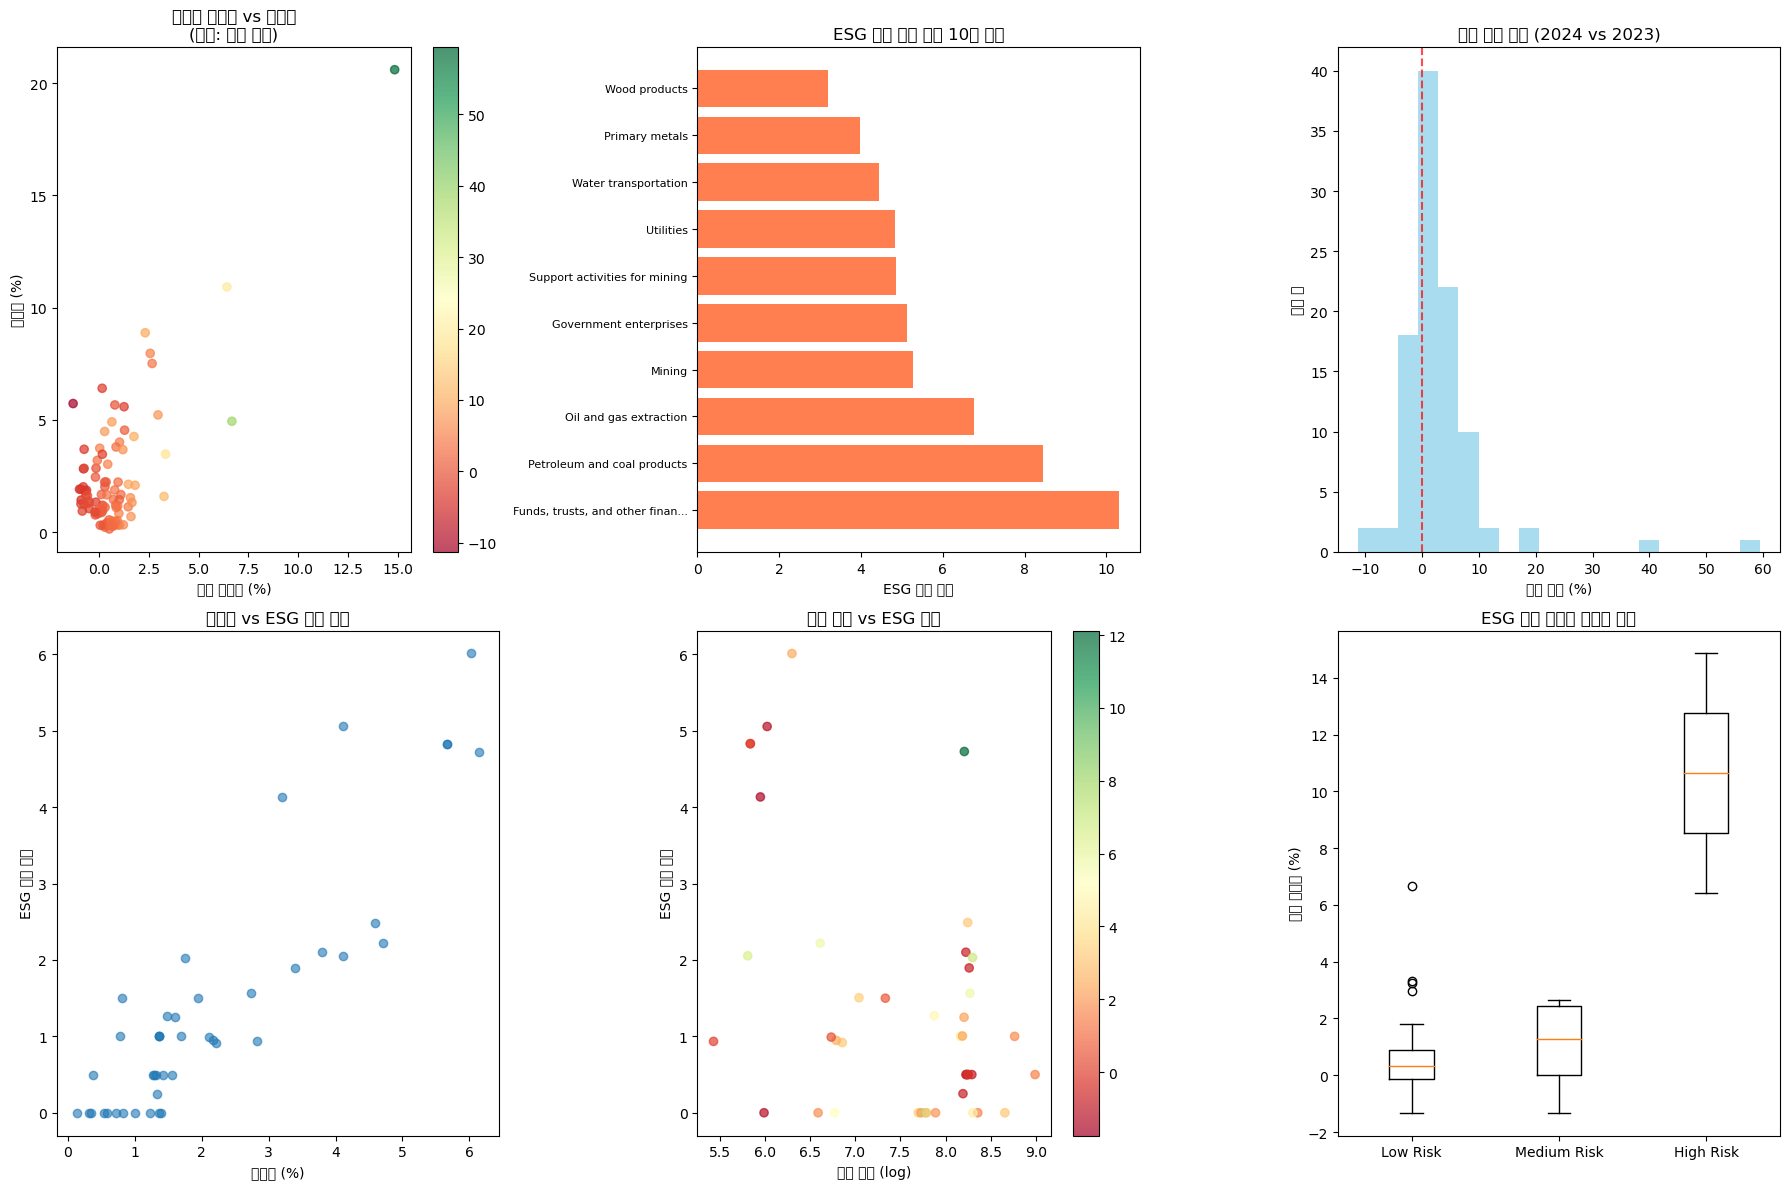


8. 실제 데이터 기반 ESG 충격 시나리오 생성...
생성된 시나리오: 10개

✅ 분석 완료!
   - 분석된 산업 수: 100
   - 원본 엣지 수: 2517
   - 매핑된 ICIO 코드 수: 44
   - 강화된 엣지 수: 2517
   - 생성된 시나리오 수: 10

실제 부가가치 데이터 활용 방법:
1. 산업별 실제 성과 트렌드 분석
2. ESG 충격 위험이 높은 산업 식별
3. 실제 데이터 기반 충격 시나리오 생성
4. 공급망 전파 효과의 현실적 검증

실행 명령:
results = integrate_real_data_analysis()


In [62]:
if __name__ == "__main__":

    print("\n" + "="*50)
    print("방법 2: 파일 경로 제공으로 자동 실행")
    
    try:
        results = integrate_real_data_analysis(
            icio_file_path='/Users/jiminbyun/Downloads/NATIOTTL/USA2020ttl.csv',
            real_value_file_path='Real Value Added by Industry.csv'
        )
        print("\n 분석 완료!")
        print(f"   - 분석된 산업 수: {len(results['growth_df'])}")
        print(f"   - 원본 엣지 수: {len(results.get('edge_df', []))}")
        print(f"   - 매핑된 ICIO 코드 수: {len(results['node_features_df'])}")
        print(f"   - 강화된 엣지 수: {len(results['enhanced_edge_df'])}")
        print(f"   - 생성된 시나리오 수: {len(results['real_scenarios'])}")
        
    except FileNotFoundError as e:
        print(f"파일을 찾을 수 없습니다: {e}")
        print("파일 경로를 확인해주세요.")
    except Exception as e:
        print(f"오류가 발생했습니다: {e}")
        import traceback
        traceback.print_exc()

print("\n" + "="*60)
print("실제 부가가치 데이터 활용 방법:")
print("1. 산업별 실제 성과 트렌드 분석")
print("2. ESG 충격 위험이 높은 산업 식별") 
print("3. 실제 데이터 기반 충격 시나리오 생성")
print("4. 공급망 전파 효과의 현실적 검증")
print("\n실행 명령:")
print("results = integrate_real_data_analysis()")
print("="*60)